In [1]:
import os, json, shutil
from pathlib import Path
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from tqdm import tqdm
from glob import glob
import pandas as pd
from medpy.metric.binary import hd95 as medpy_hd95
import torch

SPLIT_ROOT = Path(r"D:\brats_goat_experiments\data\split")
TRAIN_DIR = SPLIT_ROOT / "train"
VAL_DIR = SPLIT_ROOT / "val"
TEST_DIR = SPLIT_ROOT / "test"

NNUNET_BASE = Path(r"D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT")
NNUNET_RAW = NNUNET_BASE / "nnUNet_raw"
NNUNET_PREP = NNUNET_BASE / "nnUNet_preprocessed"
NNUNET_RES = NNUNET_BASE / "nnUNet_results"

for p in [NNUNET_RAW, NNUNET_PREP, NNUNET_RES]:
    p.mkdir(parents=True, exist_ok=True)

os.environ["nnUNet_raw"] = str(NNUNET_RAW)
os.environ["nnUNet_preprocessed"] = str(NNUNET_PREP)
os.environ["nnUNet_results"] = str(NNUNET_RES)

DATASET_ID = 907
DATASET_NAME = "BraTS-GoAT_ResEnc"
DATASET_FOLDER = NNUNET_RAW / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
imagesTr = DATASET_FOLDER / "imagesTr"
labelsTr = DATASET_FOLDER / "labelsTr"
imagesTs = DATASET_FOLDER / "imagesTs"

for p in [imagesTr, labelsTr, imagesTs]:
    p.mkdir(parents=True, exist_ok=True)

# Configuração ResEnc nnUNetv2
PLANNER    = "nnUNetPlannerResEncM"    # Planner M
PLANS_NAME = "nnUNetResEncUNetMPlans"    
TRAINER    = "nnUNetTrainer_100epochs" # 100 epocas
CONFIG     = "3d_fullres"
FOLD       = 0

DATASET_FOLDER

WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT/nnUNet_raw/Dataset907_BraTS-GoAT_ResEnc')

In [2]:
# Lê IDs de pacientes a partir das pastas
def get_patient_ids(directory: Path) -> list:
    if not directory.exists():
        return []
    return sorted([d.name for d in directory.iterdir() if d.is_dir()])

train_ids = get_patient_ids(TRAIN_DIR)
val_ids = get_patient_ids(VAL_DIR)
test_subfolders = {d.name: d for d in TEST_DIR.iterdir() if d.is_dir()}

print(f"Train: {len(train_ids)} pacientes")
print(f"Val: {len(val_ids)} pacientes")
print(f"Test subfolders: {list(test_subfolders.keys())}")
print("OK: estrutura de pastas verificada")

Train: 945 pacientes
Val: 202 pacientes
Test subfolders: ['PED', 'SSA', 'test_GLI-MET-MEN']
OK: estrutura de pastas verificada


In [3]:
MODS = ["t1n", "t1c", "t2w", "t2f"]
FILE_ENDING = ".nii.gz"

def case_dir(split_name: str, case_id: str) -> Path:
    if split_name == "train":
        return TRAIN_DIR / case_id
    elif split_name == "val":
        return VAL_DIR / case_id
    elif split_name.startswith("test"):
        test_subfolder = split_name.split("/")[1] if "/" in split_name else split_name
        return TEST_DIR / test_subfolder / case_id
    return None

def find_file(folder: Path, key: str) -> Path:
    for cand in [folder / f"{key}.nii.gz", folder / f"{key}.nii"]:
        if cand.exists():
            return cand
    cands = sorted(list(folder.glob(f"*{key}*.nii*")))
    if key == "t1n":
        cands = [c for c in cands if "t1c" not in c.name.lower()]
    if not cands:
        raise FileNotFoundError(f"{key} not found in {folder}")
    return cands[0]

def save_as_niigz(src_path: Path, dst_path: Path):
    if src_path.name.lower().endswith(".nii.gz"):
        shutil.copy2(src_path, dst_path)
        return
    img = nib.load(str(src_path))
    nib.save(img, str(dst_path))

def save_label_remap_niigz(seg_path: Path, dst_path: Path):
    img = nib.load(str(seg_path))
    data = np.asanyarray(img.dataobj).astype(np.int16)
    out = nib.Nifti1Image(data, img.affine, img.header)
    nib.save(out, str(dst_path))

def check_case(split_name: str, case_id: str):
    d = case_dir(split_name, case_id)
    assert d.exists(), f"Missing folder: {d}"
    _ = [find_file(d, m) for m in MODS]
    _ = find_file(d, "seg")
    return True

for cid in train_ids[:3]:
    check_case("train", cid)
print("OK")

OK


In [4]:
def export_case_to_nnunet(split_name: str, case_id: str, to_images: Path, to_labels: Path | None):
    d = case_dir(split_name, case_id)
    for ch, mod in enumerate(MODS):
        src = find_file(d, mod)
        dst = to_images / f"{case_id}_{ch:04d}{FILE_ENDING}"
        save_as_niigz(src, dst)
    if to_labels is not None:
        seg = find_file(d, "seg")
        dst = to_labels / f"{case_id}{FILE_ENDING}"
        save_label_remap_niigz(seg, dst)

for cid in tqdm(train_ids, desc="Export train -> imagesTr/labelsTr"):
    export_case_to_nnunet("train", cid, imagesTr, labelsTr)

for cid in tqdm(val_ids, desc="Export val -> imagesTr/labelsTr"):
    export_case_to_nnunet("val", cid, imagesTr, labelsTr)

case_to_subfolder = {}
test_ids_by_subfolder = {}

for subfolder_name, subfolder_path in test_subfolders.items():
    ids = get_patient_ids(subfolder_path)
    test_ids_by_subfolder[subfolder_name] = ids
    for cid in tqdm(ids, desc=f"Export {subfolder_name} -> imagesTs"):
        export_case_to_nnunet(f"test/{subfolder_name}", cid, imagesTs, None)
        case_to_subfolder[cid] = subfolder_name

print(f"Total train:  {len(list(imagesTr.glob(f'*{FILE_ENDING}')))}")
print(f"Total labels: {len(list(labelsTr.glob(f'*{FILE_ENDING}')))}")
print(f"Total test:   {len(list(imagesTs.glob(f'*{FILE_ENDING}')))}")
print("Distribuição teste:")
for sub, ids in test_ids_by_subfolder.items():
    print(f"  {sub}: {len(ids)} pacientes")

Export test_GLI-MET-MEN -> imagesTs: 100%|██████████| 204/204 [00:06<00:00, 32.89it/s]

Total train:  4588
Total labels: 1147
Total test:   1796
Distribuição teste:
  PED: 99 pacientes
  SSA: 146 pacientes
  test_GLI-MET-MEN: 204 pacientes


In [5]:
dataset_json = {
    "channel_names": {"0": "T1n", "1": "T1c", "2": "T2w", "3": "T2f"},
    "labels": {"background": 0, "NCR/NET": 1, "ED": 2, "ET": 3},
    "numTraining": len(list(labelsTr.glob(f"*{FILE_ENDING}"))),
    "file_ending": FILE_ENDING
}

with open(DATASET_FOLDER / "dataset.json", "w", encoding="utf-8") as f:
    json.dump(dataset_json, f, indent=2, ensure_ascii=False)

DATASET_FOLDER / "dataset.json"

WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT/nnUNet_raw/Dataset907_BraTS-GoAT_ResEnc/dataset.json')

In [6]:
!nnUNetv2_plan_and_preprocess -d {DATASET_ID} --verify_dataset_integrity -pl {PLANNER} -c {CONFIG} -np 4

Fingerprint extraction...
Dataset907_BraTS-GoAT_ResEnc
Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer

####################
verify_dataset_integrity Done. 
If you didn't see any error messages then your dataset is most likely OK!
####################

Using <class 'nnunetv2.imageio.simpleitk_reader_writer.SimpleITKIO'> as reader/writer
Experiment planning...
Dropping 3d_lowres config because the image size difference to 3d_fullres is too small. 3d_fullres: [140. 171. 136.], 3d_lowres: [140, 171, 136]
2D U-Net configuration:
{'data_identifier': 'nnUNetPlans_2d', 'preprocessor_name': 'DefaultPreprocessor', 'batch_size': 107, 'patch_size': (np.int64(192), np.int64(160)), 'median_image_size_in_voxels': array([171., 136.]), 'spacing': array([1., 1.]), 'normalization_schemes': ['ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization', 'ZScoreNormalization'], 'use_mask_for_norm': [True, True, True, True], 'resampling_fn_data': 'resample_data_o


100%|##########| 1147/1147 [02:05<00:00,  9.14it/s]

100%|##########| 1147/1147 [24:28<00:00,  1.28s/it]


In [7]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
preprocessed_dataset.exists()

True

In [8]:
preprocessed_dataset = NNUNET_PREP / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
splits_final = [{"train": sorted(train_ids), "val": sorted(val_ids)}]
with open(preprocessed_dataset / "splits_final.json", "w", encoding="utf-8") as f:
    json.dump(splits_final, f, indent=2, ensure_ascii=False)

preprocessed_dataset / "splits_final.json"

WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT/nnUNet_preprocessed/Dataset907_BraTS-GoAT_ResEnc/splits_final.json')

In [9]:
prep = Path(os.environ["nnUNet_preprocessed"]) / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}"
print("Preprocessed dir:", prep)

plans_files = list(prep.glob(f"{PLANS_NAME}*.json"))
print("Plans files:", plans_files)

if plans_files:
    with open(plans_files[0], "r", encoding="utf-8") as f:
        plans_json = json.load(f)
    print("Top keys:", plans_json.keys())

Preprocessed dir: D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT\nnUNet_preprocessed\Dataset907_BraTS-GoAT_ResEnc
Plans files: [WindowsPath('D:/brats_goat_experiments/models_configs/nnUNet_ResEnc_GOAT/nnUNet_preprocessed/Dataset907_BraTS-GoAT_ResEnc/nnUNetResEncUNetMPlans.json')]
Top keys: dict_keys(['dataset_name', 'plans_name', 'original_median_spacing_after_transp', 'original_median_shape_after_transp', 'image_reader_writer', 'transpose_forward', 'transpose_backward', 'configurations', 'experiment_planner_used', 'label_manager', 'foreground_intensity_properties_per_channel'])


In [10]:
!nnUNetv2_train {DATASET_ID} {CONFIG} {FOLD} -device cuda -p {PLANS_NAME} -tr {TRAINER}

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

2026-05-11 23:14:14.188757: do_dummy_2d_data_aug: False
2026-05-11 23:14:14.204467: Using splits from existing split file: D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT\nnUNet_preprocessed\Dataset907_BraTS-GoAT_ResEnc\splits_final.json
2026-05-11 23:14:14.204467: The split file contains 1 splits.
2026-05-11 23:14:14.204467: Desired fold for training: 0
2026-05-11 23:14:14.204467: This split has 945 training and 202 validation cases.
using pin_memory on device 0
using pin_memory on device 0

This is the configuration used by this training:
Configuration nam

In [11]:
pattern = str(NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / "*" / f"fold_{FOLD}" / "validation" / "summary.json")
cands = glob(pattern)
cands[:2], len(cands)

(['D:\\brats_goat_experiments\\models_configs\\nnUNet_ResEnc_GOAT\\nnUNet_results\\Dataset907_BraTS-GoAT_ResEnc\\nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__3d_fullres\\fold_0\\validation\\summary.json'],
 1)

In [12]:
if cands:
    with open(cands[0], "r", encoding="utf-8") as f:
        summary = json.load(f)
    list(summary.keys())

In [13]:
# Inferência para todo o conjunto de teste
PRED_TEST_OUT = Path(r"D:\nnUNet_preds\brats_goat_resenc_test_pred")
PRED_TEST_OUT.mkdir(parents=True, exist_ok=True)

!nnUNetv2_predict -i "{imagesTs}" -o "{PRED_TEST_OUT}" -d {DATASET_ID} -c {CONFIG} -f {FOLD} -p {PLANS_NAME} -tr {TRAINER}


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 449 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 449 cases that I would like to predict

Predicting BraTS-GoAT-00003:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS-GoAT-00003

Predicting BraTS-GoAT-00014:
perform_everything_on_device: True
sending off prediction to background worker for resampling and export
done with BraTS-GoAT-00014

Predicting BraTS-GoAT-00025:
perform_everything_on_device: True
sending off prediction to background worke


100%|##########| 8/8 [00:04<00:00,  1.70it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.24it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|##########| 4/4 [00:01<00:00,  2.28it/s]

100%|##########| 8/8 [00:03<00:00,  2.26it/s]

100%|##########| 8/8 [00:03<00:00,  2.25it/s]

100%|#######

In [14]:
def load_arr(p):
    arr = np.asanyarray(nib.load(str(p)).dataobj)
    return np.squeeze(arr)
    
def dice(a, b):
    inter = np.count_nonzero(a & b)
    denom = np.count_nonzero(a) + np.count_nonzero(b)
    return 1.0 if denom == 0 else (2.0 * inter / denom)

def get_pred_path(cid: str) -> Path:
    p = PRED_TEST_OUT / f"{cid}.nii.gz"
    if p.exists():
        return p
    p = PRED_TEST_OUT / f"{cid}.nii"
    if p.exists():
        return p
    raise FileNotFoundError(f"Pred não encontrada para {cid}")

all_test_ids = [cid for ids in test_ids_by_subfolder.values() for cid in ids]

rows = []
for cid in tqdm(all_test_ids, desc="Dice por caso"):
    sub = case_to_subfolder[cid]
    gt_path = find_file(case_dir(f"test/{sub}", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))

    rows.append({
        "id":       cid,
        "subfolder": sub,
        "dice_c1":  d1,
        "dice_c2":  d2,
        "dice_ET":  d3,
        "dice_WT":  wt,
        "dice_TC":  tc,
    })

df = pd.DataFrame(rows)
df[["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

Dice por caso: 100%|██████████| 449/449 [01:12<00:00,  6.20it/s]


,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,449.000000,449.000000,449.000000,449.000000,449.000000
mean,0.614523,0.670426,0.755072,0.898257,0.776008
std,0.349316,0.350822,0.295902,0.138854,0.286059
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.321449,0.563136,0.750038,0.894057,0.728717
50%,0.753068,0.835546,0.876402,0.933925,0.911238
75%,0.913218,0.934712,0.931980,0.961053,0.957996
max,1.000000,1.000000,1.000000,0.991896,1.000000


In [15]:
# HD95 (Hausdorff Distance 95) por caso

def hd95_score(gt_mask, pr_mask, voxelspacing=None):
    gt_b = gt_mask.astype(bool)
    pr_b = pr_mask.astype(bool)
    if not gt_b.any() and not pr_b.any():
        return 0.0
    if not gt_b.any() or not pr_b.any():
        return np.nan
    return float(medpy_hd95(pr_b, gt_b, voxelspacing=voxelspacing))


hd95_rows = []
for cid in tqdm(all_test_ids, desc="HD95 por caso"):
    sub = case_to_subfolder[cid]
    gt_path = find_file(case_dir(f"test/{sub}", cid), "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    spacing = nib.load(str(gt_path)).header.get_zooms()[:3]

    h1  = hd95_score(gt == 1, pr == 1, voxelspacing=spacing)
    h2  = hd95_score(gt == 2, pr == 2, voxelspacing=spacing)
    h3  = hd95_score(gt == 3, pr == 3, voxelspacing=spacing)
    hwt = hd95_score(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)), voxelspacing=spacing)
    htc = hd95_score(((gt == 1) | (gt == 3)),   ((pr == 1) | (pr == 3)),   voxelspacing=spacing)

    hd95_rows.append({
        "id":       cid,
        "subfolder": sub,
        "hd95_c1":  h1,
        "hd95_c2":  h2,
        "hd95_ET":  h3,
        "hd95_WT":  hwt,
        "hd95_TC":  htc,
    })

df_hd95 = pd.DataFrame(hd95_rows)
df_hd95[["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

HD95 por caso: 100%|██████████| 449/449 [37:25<00:00,  5.00s/it]


,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,424.000000,405.000000,423.000000,447.000000,443.000000
mean,9.493198,8.772951,6.361527,6.173521,9.318983
std,12.682197,13.919092,13.413812,10.557678,14.918541
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.414214,1.732051,1.000000,1.732051,1.414214
50%,4.415517,3.316625,2.000000,3.000000,3.000000
75%,12.369317,7.348469,3.741657,5.196152,11.378088
max,100.379270,91.268834,85.954627,86.994252,96.798760


In [16]:
def norm01(x, p1=1, p99=99):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, [p1, p99])
    if hi <= lo:
        return np.zeros_like(x, dtype=np.float32)
    x = (x - lo) / (hi - lo)
    return np.clip(x, 0, 1)

def overlay(ax, base2d, mask2d, color_rgb, alpha=0.45, title=""):
    ax.imshow(base2d, cmap="gray", origin="lower")
    rgba = np.zeros((mask2d.shape[0], mask2d.shape[1], 4), dtype=np.float32)
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = color_rgb
    rgba[..., 3] = mask2d.astype(np.float32) * alpha
    ax.imshow(rgba, origin="lower")
    ax.set_title(title)
    ax.axis("off")

def pick_best_slice(gt):
    counts = (gt > 0).sum(axis=(0, 1))
    return int(counts.argmax())

cmap_mask = ListedColormap([
    (0, 0, 0, 1),
    (1, 0, 0, 1),
    (0, 1, 0, 1),
    (0, 0, 1, 1),
])
norm_mask = BoundaryNorm([0, 1, 2, 3, 4], cmap_mask.N)

def masks_from_seg(seg):
    nec = (seg == 1)
    ede = (seg == 2)
    enh = (seg == 3)
    wt  = (seg == 1) | (seg == 2) | (seg == 3)
    tc  = (seg == 1) | (seg == 3)
    return nec, ede, enh, wt, tc

def plot_random_case_multimodal_gt_pred(
    ids_list,
    split_name="test",
    seed=None,
    z=None,
    alpha_cls=0.45,
    alpha_comp=0.35,
):
    rng = np.random.default_rng(seed)
    cid = str(rng.choice(ids_list))

    d = case_dir(split_name, cid)

    gt_path = find_file(d, "seg")
    pr_path = get_pred_path(cid)

    gt = load_arr(gt_path).astype(np.int16)
    pr = load_arr(pr_path).astype(np.int16)

    if z is None:
        z = pick_best_slice(gt)

    d1 = dice(gt == 1, pr == 1)
    d2 = dice(gt == 2, pr == 2)
    d3 = dice(gt == 3, pr == 3)
    wt = dice(((gt==1)|(gt==2)|(gt==3)), ((pr==1)|(pr==2)|(pr==3)))
    tc = dice(((gt == 1) | (gt == 3)), ((pr == 1) | (pr == 3)))

    print(f"\nPaciente: {cid} | split={split_name} | z={z}")
    print(f"Dice C1 (necrose/non-enh): {d1:.4f}")
    print(f"Dice C2 (edema):           {d2:.4f}")
    print(f"Dice ET (enhancing):       {d3:.4f}")
    print(f"Dice WT:                   {wt:.4f}")
    print(f"Dice TC:                   {tc:.4f}\n")

    gt2d = gt[:, :, z].T
    pr2d = pr[:, :, z].T

    gt_nec, gt_ede, gt_enh, gt_wt, gt_tc = masks_from_seg(gt2d)
    pr_nec, pr_ede, pr_enh, pr_wt, pr_tc = masks_from_seg(pr2d)

    n_mods = len(MODS)
    nrows = 2 * n_mods
    ncols = 7

    fig, axes = plt.subplots(nrows, ncols, figsize=(28, 3.2 * nrows))
    fig.suptitle(f"{cid} | z={z}", y=1.01)

    for i, mod in enumerate(MODS):
        img_path = find_file(d, mod)
        img = load_arr(img_path)
        img2d = norm01(img[:, :, z]).T

        r_gt = 2 * i
        r_pr = 2 * i + 1

        axes[r_gt, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_gt, 0].set_title(f"GT • Original ({mod})")
        axes[r_gt, 0].axis("off")

        axes[r_gt, 1].imshow(gt2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_gt, 1].set_title("GT • Mask")
        axes[r_gt, 1].axis("off")

        overlay(axes[r_gt, 2], img2d, gt_ede, (0, 1, 0), alpha=alpha_cls,  title="GT • Edema (2)")
        overlay(axes[r_gt, 3], img2d, gt_nec, (1, 0, 0), alpha=alpha_cls,  title="GT • Necrose (1)")
        overlay(axes[r_gt, 4], img2d, gt_enh, (0, 0, 1), alpha=alpha_cls,  title="GT • Enhancing (3)")
        overlay(axes[r_gt, 5], img2d, gt_wt,  (1, 1, 0), alpha=alpha_comp, title="GT • Whole Tumor (WT)")
        overlay(axes[r_gt, 6], img2d, gt_tc,  (1, 0, 1), alpha=alpha_comp, title="GT • Tumor Core (TC)")

        axes[r_pr, 0].imshow(img2d, cmap="gray", origin="lower")
        axes[r_pr, 0].set_title(f"PRED • Original ({mod})")
        axes[r_pr, 0].axis("off")

        axes[r_pr, 1].imshow(pr2d, cmap=cmap_mask, norm=norm_mask, origin="lower")
        axes[r_pr, 1].set_title("PRED • Mask")
        axes[r_pr, 1].axis("off")

        overlay(axes[r_pr, 2], img2d, pr_ede, (0, 1, 0), alpha=alpha_cls,  title="PRED • Edema (2)")
        overlay(axes[r_pr, 3], img2d, pr_nec, (1, 0, 0), alpha=alpha_cls,  title="PRED • Necrose (1)")
        overlay(axes[r_pr, 4], img2d, pr_enh, (0, 0, 1), alpha=alpha_cls,  title="PRED • Enhancing (3)")
        overlay(axes[r_pr, 5], img2d, pr_wt,  (1, 1, 0), alpha=alpha_comp, title="PRED • Whole Tumor (WT)")
        overlay(axes[r_pr, 6], img2d, pr_tc,  (1, 0, 1), alpha=alpha_comp, title="PRED • Tumor Core (TC)")

    plt.tight_layout()
    plt.show()

    return cid, z, {"dice_c1": d1, "dice_c2": d2, "dice_ET": d3, "dice_WT": wt, "dice_TC": tc}

Lendo histórico de: D:\brats_goat_experiments\models_configs\nnUNet_ResEnc_GOAT\nnUNet_results\Dataset907_BraTS-GoAT_ResEnc\nnUNetTrainer_100epochs__nnUNetResEncUNetMPlans__3d_fullres\fold_0\checkpoint_final.pth
Épocas registradas: train=100 | val=100


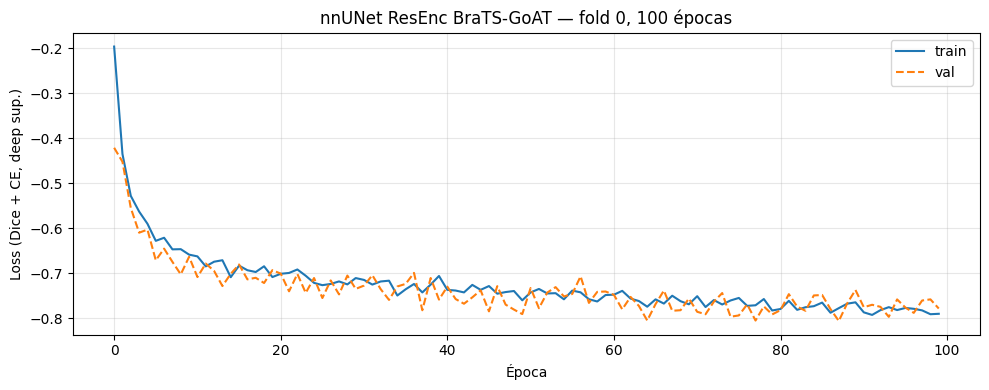

In [17]:
# Curvas de loss (treino vs validação)

trainer_dir = NNUNET_RES / f"Dataset{DATASET_ID:03d}_{DATASET_NAME}" / f"{TRAINER}__{PLANS_NAME}__{CONFIG}" / f"fold_{FOLD}"

ckpt_path = trainer_dir / "checkpoint_final.pth"
if not ckpt_path.exists():
    ckpt_path = trainer_dir / "checkpoint_best.pth"
print("Lendo histórico de:", ckpt_path)

ckpt = torch.load(str(ckpt_path), map_location="cpu", weights_only=False)
log = ckpt.get("logging", {})
train_losses = log.get("train_losses", [])
val_losses   = log.get("val_losses",   [])
print(f"Épocas registradas: train={len(train_losses)} | val={len(val_losses)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label="train")
ax.plot(val_losses,   label="val", ls="--")
ax.set_xlabel("Época")
ax.set_ylabel("Loss (Dice + CE, deep sup.)")
ax.set_title(f"nnUNet ResEnc BraTS-GoAT — fold {FOLD}, {len(train_losses)} épocas")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(trainer_dir / "loss_curves.png", dpi=150)
plt.show()

---
## test_GLI-MET-MEN

In [18]:
# Dice — test_GLI-MET-MEN
_SUB = "test_GLI-MET-MEN"
_ids = test_ids_by_subfolder[_SUB]

df[df["subfolder"] == _SUB][["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,204.000000,204.000000,204.000000,204.000000,204.000000
mean,0.799996,0.848150,0.819793,0.904197,0.892748
std,0.256551,0.178949,0.271779,0.172386,0.190929
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.765143,0.808639,0.846839,0.912128,0.902012
50%,0.903627,0.904481,0.917070,0.949329,0.955178
75%,0.963838,0.956889,0.954920,0.976971,0.976768
max,1.000000,1.000000,1.000000,0.991896,1.000000


In [19]:
# HD95 — test_GLI-MET-MEN
df_hd95[df_hd95["subfolder"] == _SUB][["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,199.000000,203.000000,192.000000,202.000000,202.000000
mean,4.093892,4.464724,5.547815,5.562015,6.786285
std,6.764031,9.144408,14.258558,11.904332,16.527702
min,0.000000,0.000000,0.000000,1.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.414214,2.000000,1.000000,2.236068,1.414214
75%,4.415517,4.123106,2.000000,3.741657,3.121708
max,44.478646,86.214848,85.954627,86.994252,96.798760



Paciente: BraTS-GoAT-01165 | split=test/test_GLI-MET-MEN | z=70
Dice C1 (necrose/non-enh): 0.9638
Dice C2 (edema):           0.8070
Dice ET (enhancing):       0.9419
Dice WT:                   0.9574
Dice TC:                   0.9712



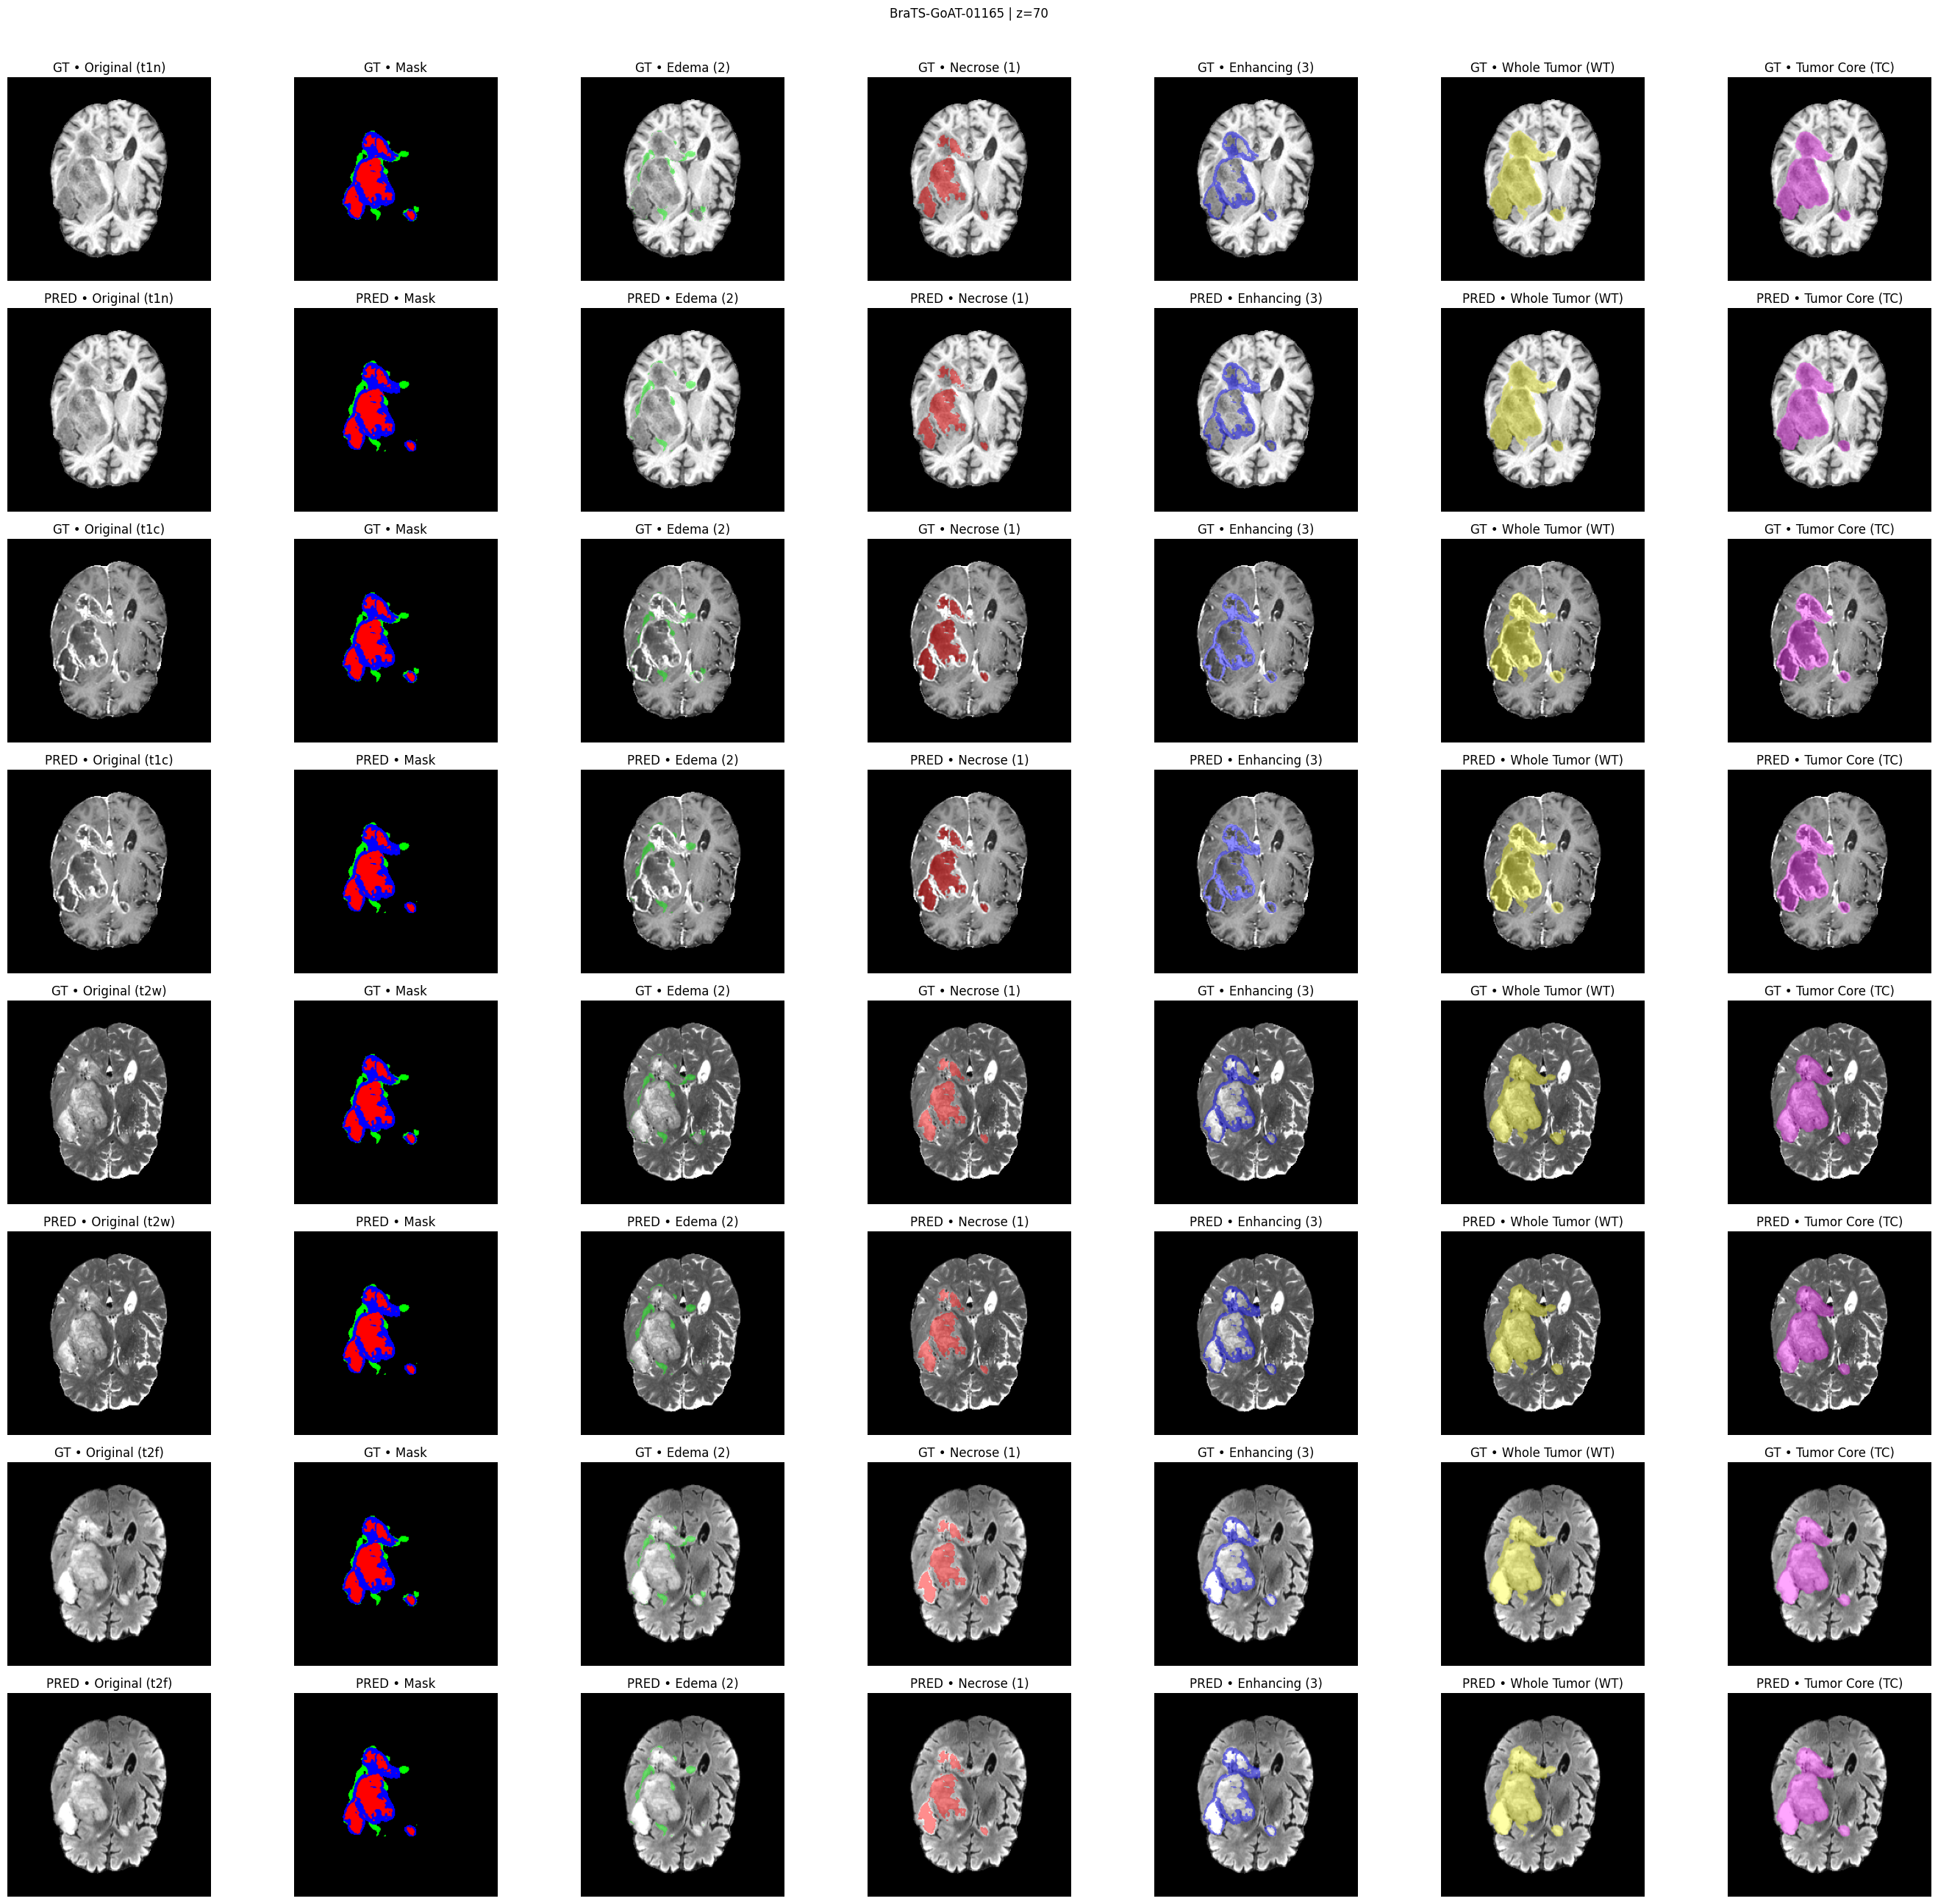

In [20]:
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(_ids, split_name=f"test/{_SUB}", seed=None)

---
## test — PED

In [21]:
# Dice — PED
_SUB = "PED"
_ids = test_ids_by_subfolder[_SUB]

df[df["subfolder"] == _SUB][["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,99.000000,99.000000,99.000000,99.000000,99.000000
mean,0.277553,0.140583,0.542882,0.879053,0.460750
std,0.289450,0.272803,0.368465,0.114085,0.309932
min,0.000000,0.000000,0.000000,0.108925,0.000000
25%,0.011362,0.000000,0.017449,0.859980,0.192013
50%,0.127486,0.000000,0.697129,0.908470,0.487871
75%,0.545564,0.107822,0.870505,0.938385,0.711942
max,0.878001,0.952008,1.000000,0.974266,0.976989


In [22]:
# HD95 — PED
df_hd95[df_hd95["subfolder"] == _SUB][["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,89.000000,57.000000,86.000000,99.000000,96.000000
mean,18.615156,29.119677,10.412835,6.411946,16.802486
std,11.421028,20.335086,17.046617,9.189599,12.641778
min,2.828427,1.414214,0.000000,1.000000,1.000000
25%,10.816654,13.152946,2.000000,2.289423,8.439012
50%,16.186414,26.925824,3.081139,3.316625,13.928388
75%,24.351591,40.931039,10.104876,6.000000,20.675809
max,57.509129,91.268834,84.963811,68.416371,64.822835



Paciente: BraTS-PED-00130-000 | split=test/PED | z=39
Dice C1 (necrose/non-enh): 0.0000
Dice C2 (edema):           0.0000
Dice ET (enhancing):       0.0001
Dice WT:                   0.1089
Dice TC:                   0.0000



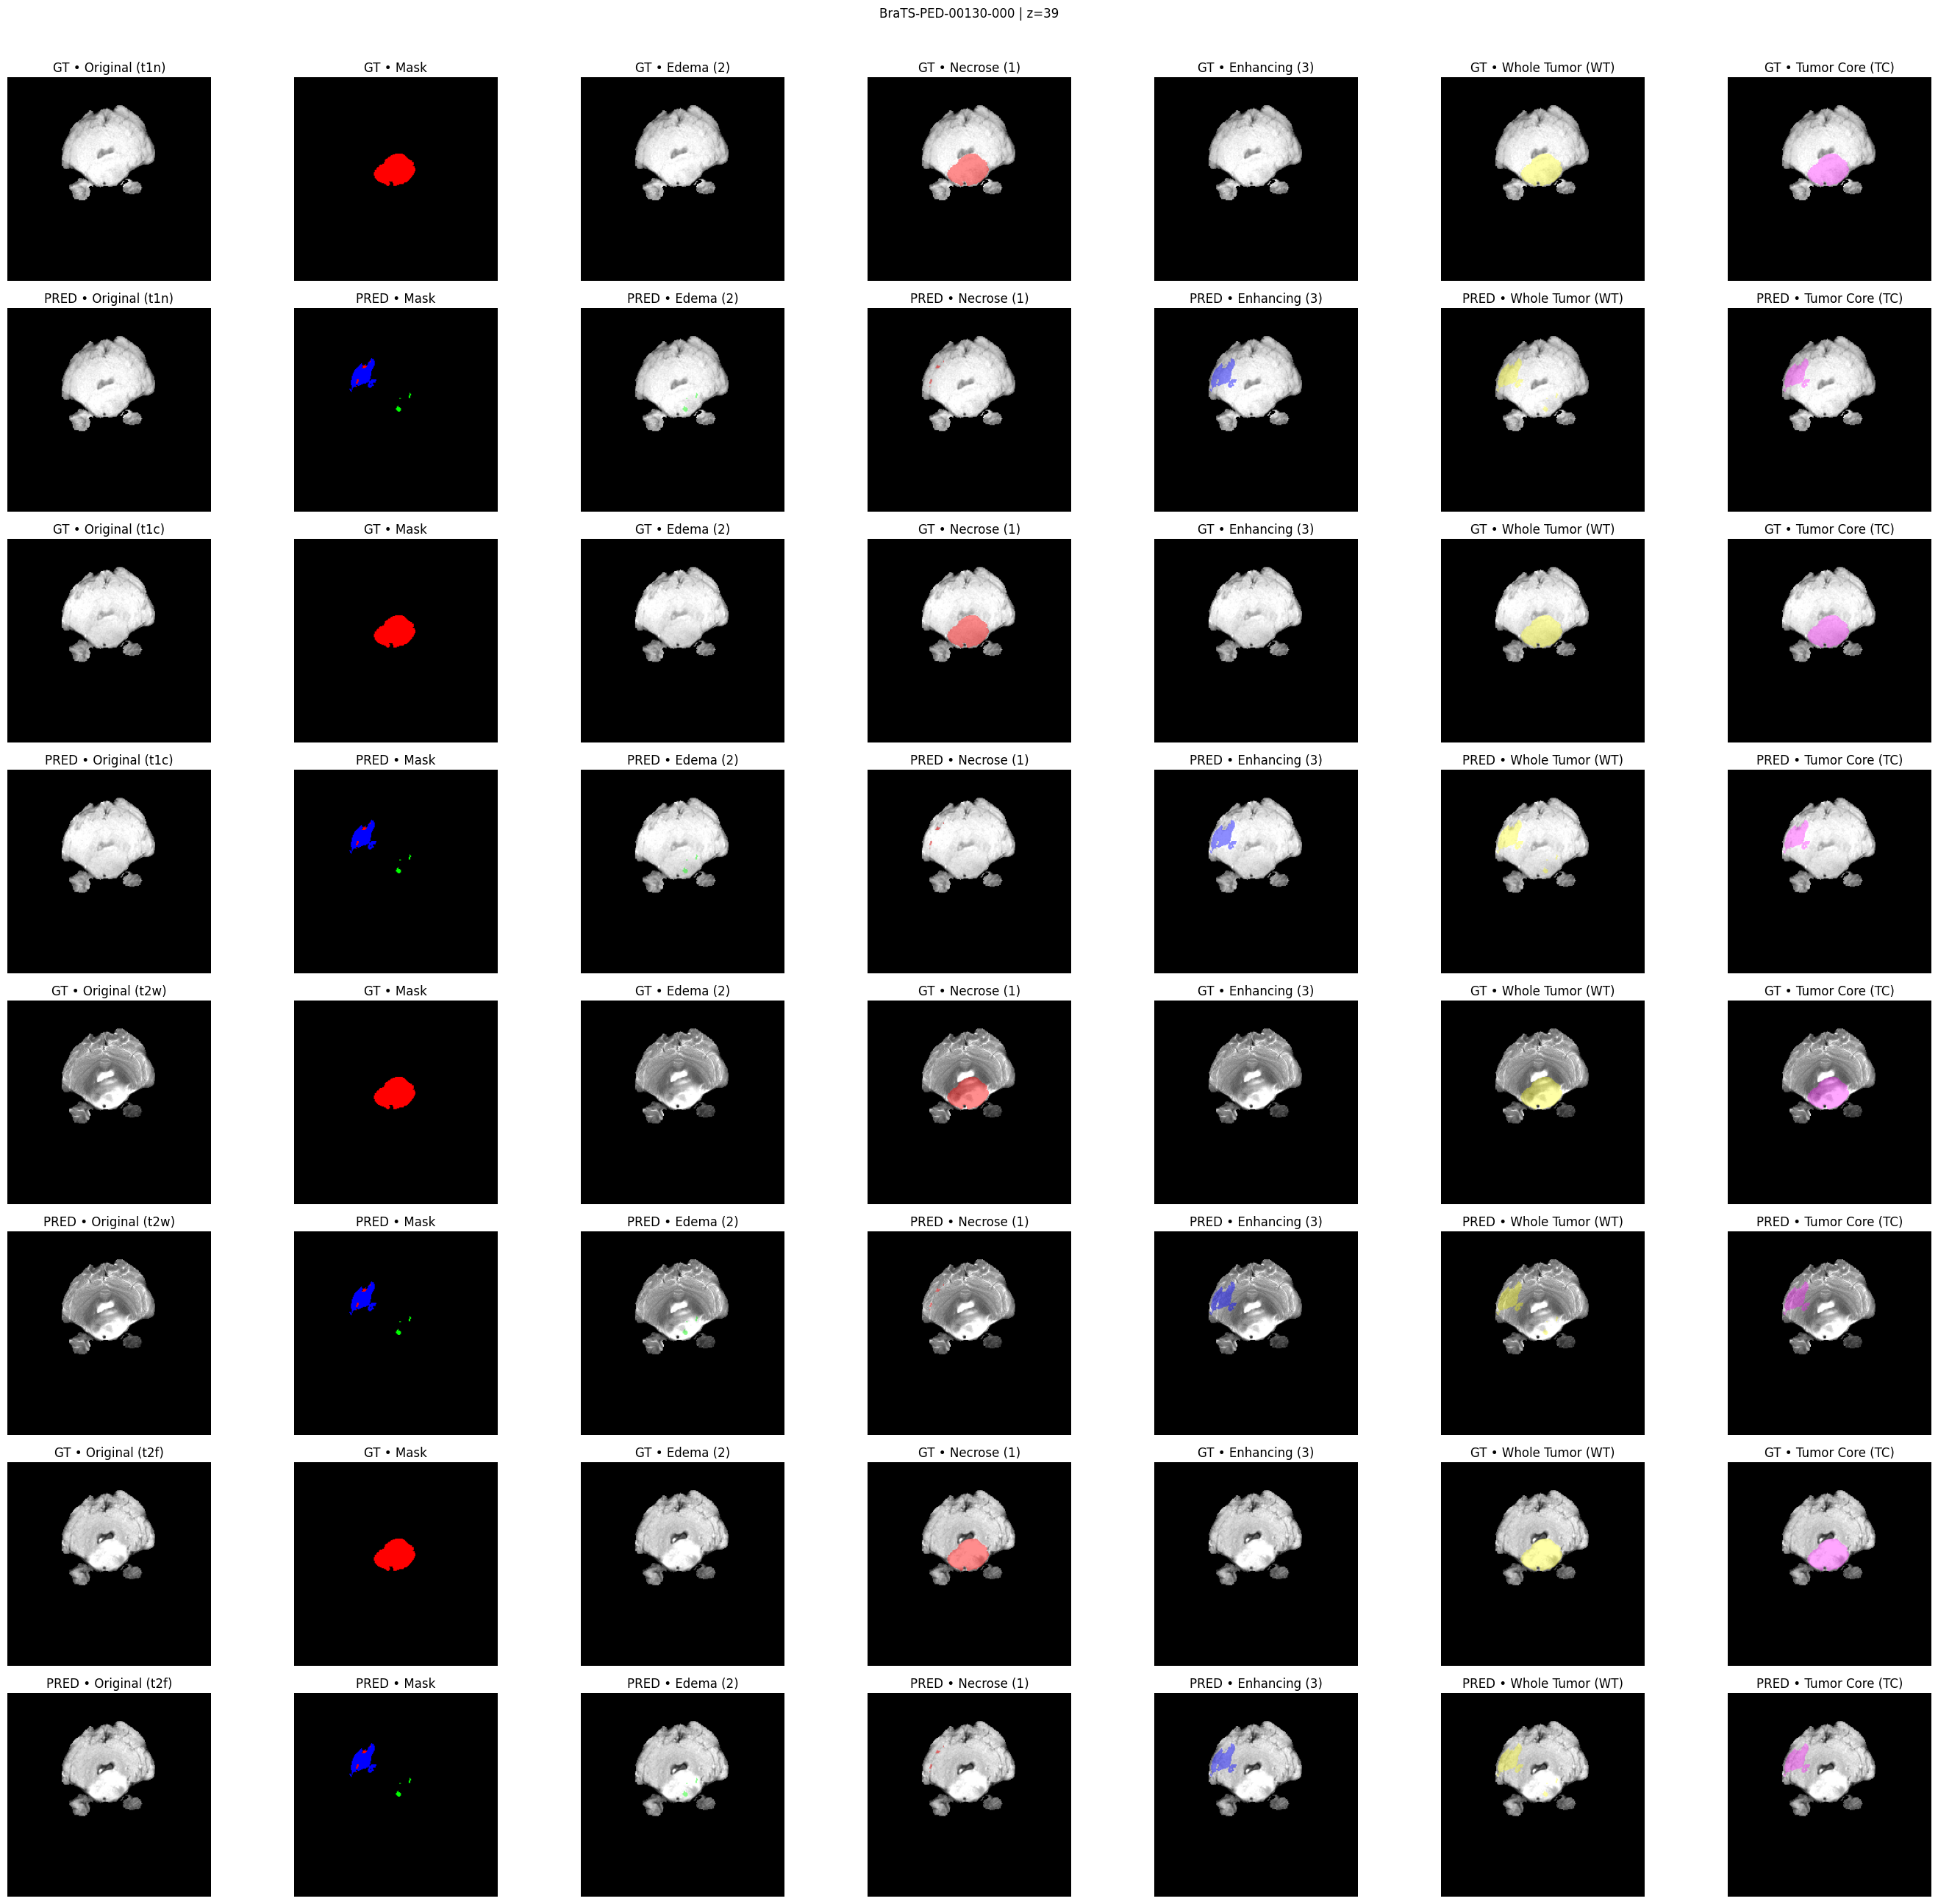

In [23]:
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(_ids, split_name=f"test/{_SUB}", seed=None)

---
## test — SSA

In [24]:
# Dice — SSA
_SUB = "SSA"
_ids = test_ids_by_subfolder[_SUB]

df[df["subfolder"] == _SUB][["dice_c1", "dice_c2", "dice_ET", "dice_WT", "dice_TC"]].describe()

,dice_c1,dice_c2,dice_ET,dice_WT,dice_TC
count,146.000000,146.000000,146.000000,146.000000,146.000000
mean,0.583862,0.781375,0.808523,0.902981,0.826662
std,0.318379,0.191382,0.189327,0.094053,0.217380
min,0.000000,0.000000,0.000000,0.326131,0.000000
25%,0.352534,0.702197,0.791058,0.893059,0.834007
50%,0.680073,0.851894,0.870883,0.930012,0.909575
75%,0.845367,0.917138,0.910867,0.954863,0.939205
max,1.000000,0.969709,1.000000,0.980615,0.981251


In [25]:
# HD95 — SSA
df_hd95[df_hd95["subfolder"] == _SUB][["hd95_c1", "hd95_c2", "hd95_ET", "hd95_WT", "hd95_TC"]].describe()

,hd95_c1,hd95_c2,hd95_ET,hd95_WT,hd95_TC
count,136.000000,145.000000,145.000000,146.000000,145.000000
mean,11.424136,6.806101,5.036149,6.857906,7.892697
std,15.819063,8.456214,8.582037,9.396747,12.167029
min,0.000000,1.000000,0.000000,1.000000,1.000000
25%,2.733693,2.236068,1.732051,2.236068,2.236068
50%,5.196152,4.123106,2.236068,3.316625,3.000000
75%,12.369317,7.071068,4.472136,6.000000,7.615773
max,100.379270,66.077984,69.921384,67.181471,76.347888



Paciente: BraTS-SSA-00126-000 | split=test/SSA | z=74
Dice C1 (necrose/non-enh): 0.9421
Dice C2 (edema):           0.8459
Dice ET (enhancing):       0.8149
Dice WT:                   0.9359
Dice TC:                   0.9516



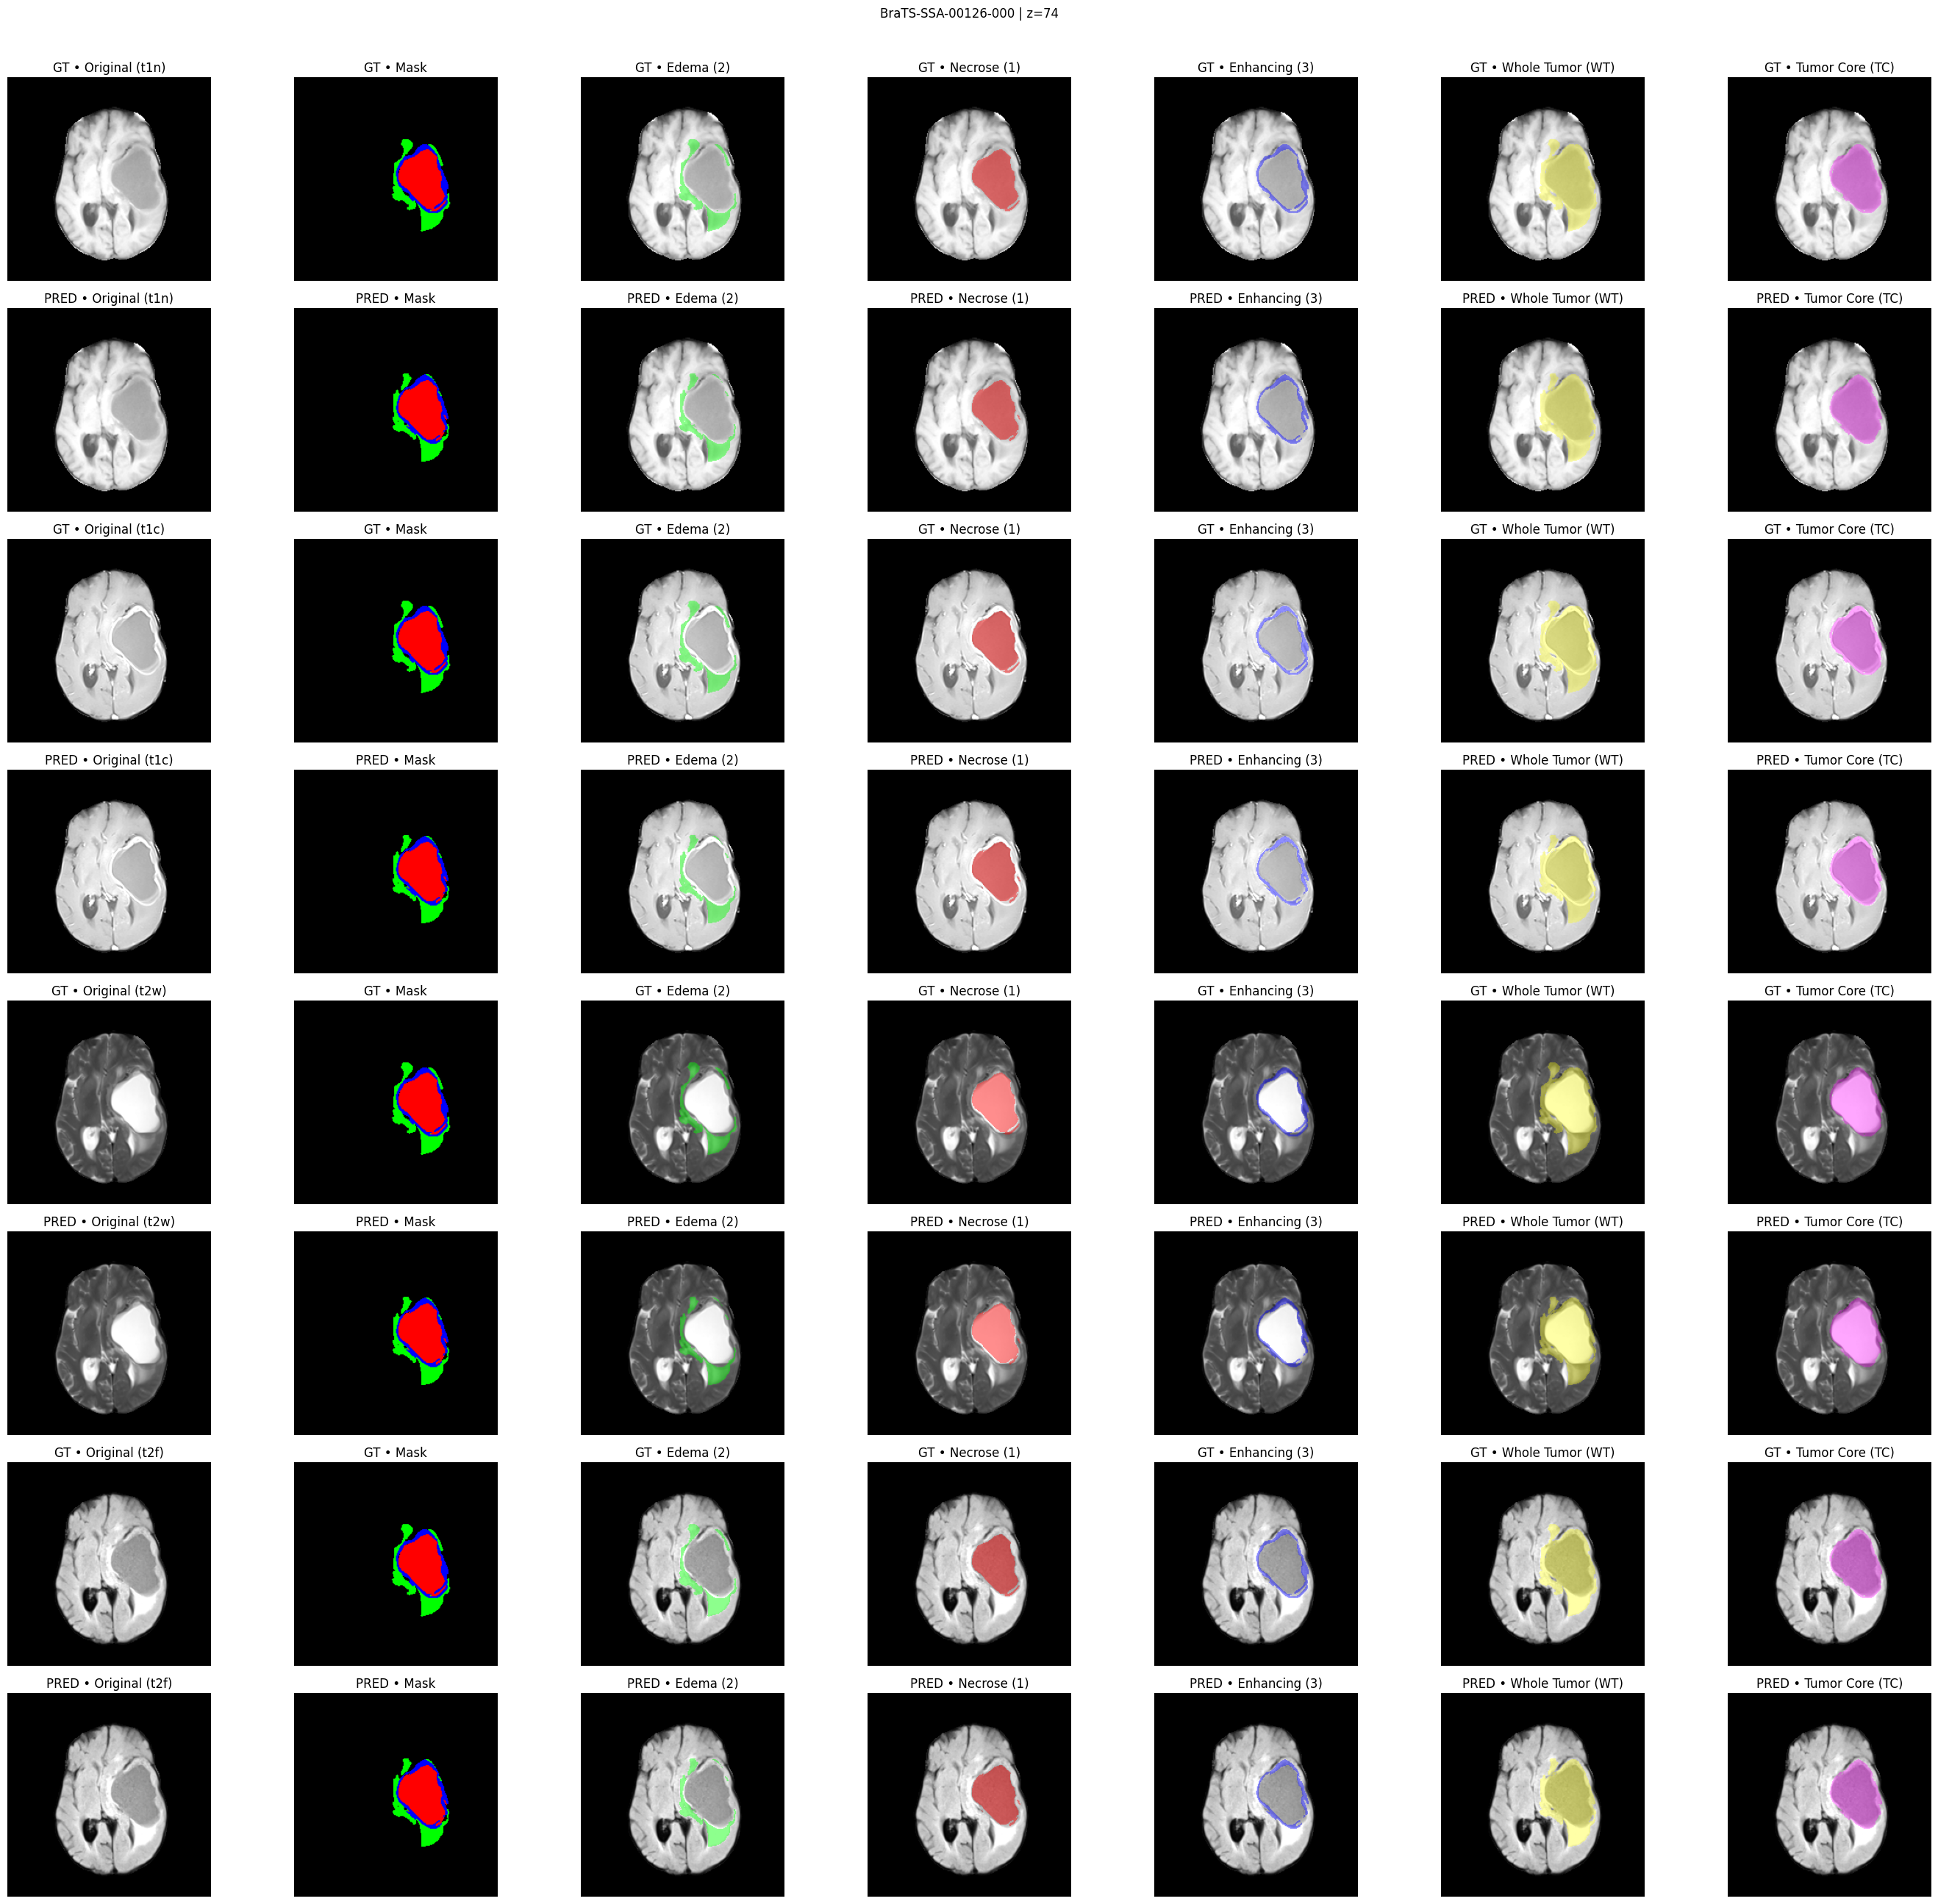

In [26]:
cid, z, dice_dict = plot_random_case_multimodal_gt_pred(_ids, split_name=f"test/{_SUB}", seed=None)